# Gauss–Lucas Theorem: Roots of Derivatives

Given a polynomial $P(z) \in \mathbb{C}[z]$ of degree $n$, what can we say about the location of the roots of its derivative $P'(z)$?

## The Gauss–Lucas theorem

**Theorem** (Gauss 1836, Lucas 1879): *The roots of $P'$ lie in the convex hull of the roots of $P$.*

More precisely, if $z_1, \ldots, z_n$ are the roots of $P$ (counted with multiplicity), then every root $w$ of $P'$ satisfies
$$
w \in \operatorname{conv}\{z_1, \ldots, z_n\}.
$$

**Proof sketch**: Write $P(z) = c \prod_{k=1}^n (z - z_k)$. Then
$$
\frac{P'(z)}{P(z)} = \sum_{k=1}^n \frac{1}{z - z_k}.
$$
If $w$ is a root of $P'$ but not of $P$, then $\sum_k \frac{1}{w - z_k} = 0$. Multiplying by $\overline{w - z_k}$ and taking the real part shows that $w$ is a barycentric combination of the $z_k$ with positive weights, hence in their convex hull.

## Repeated differentiation

Applying the theorem iteratively: differentiating $n-1$ times takes a polynomial with $n$ roots to a linear polynomial with $1$ root. The **centroid of the roots is preserved** under differentiation, and the roots collapse inward toward the convex hull's interior.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120

## Visualization: one step of differentiation

We generate a random polynomial with $n$ roots and plot the roots of $P$, $P'$, $P''$, etc. At each step, the roots lie strictly inside the convex hull of the previous generation.

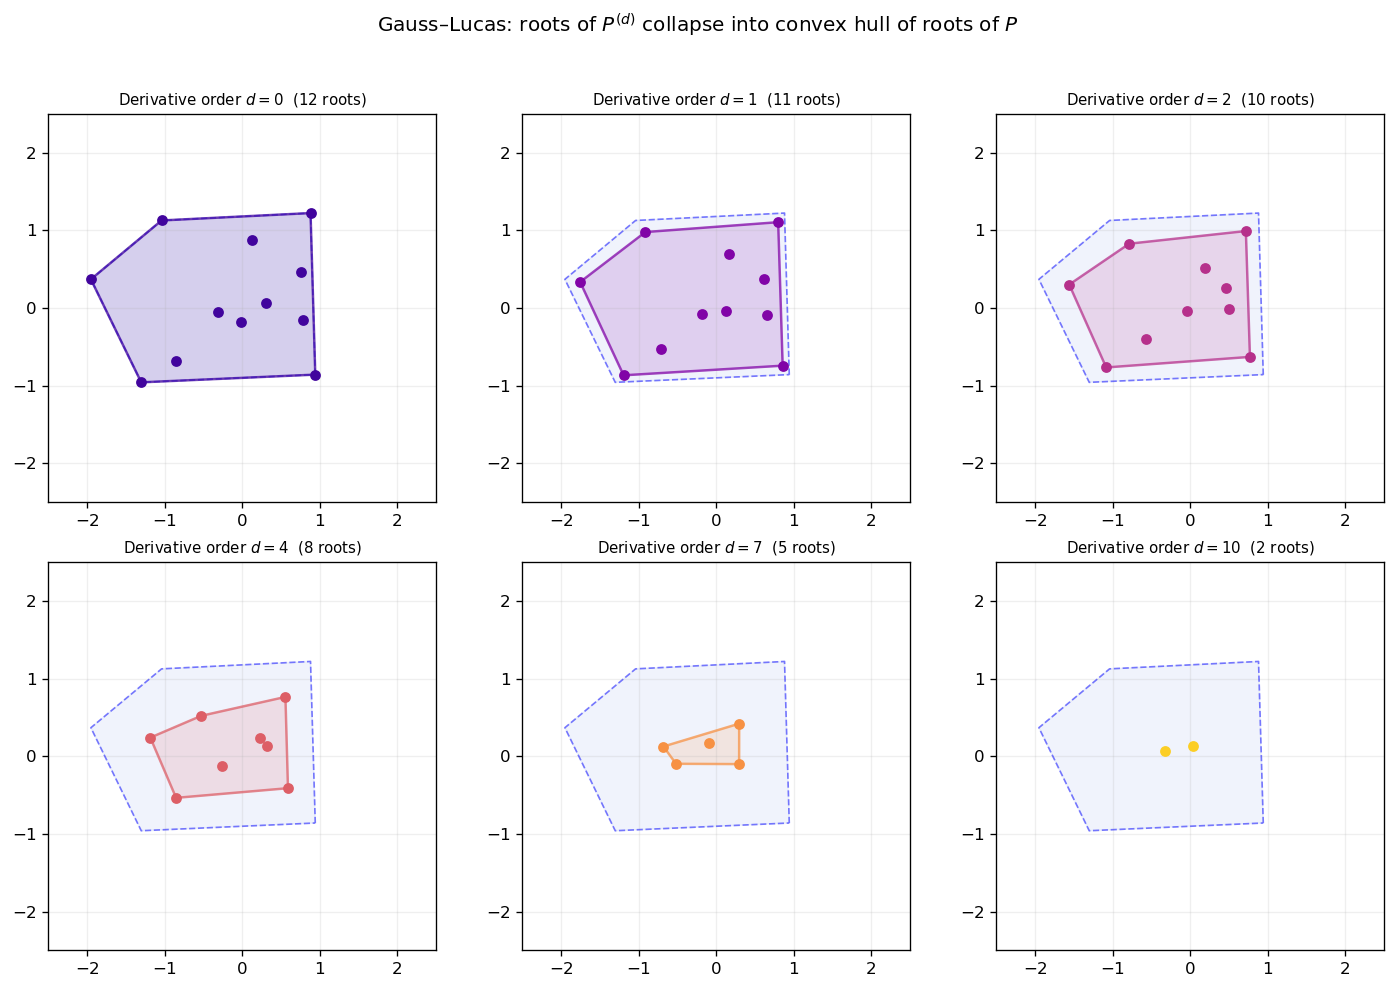

In [2]:
def poly_roots_derivatives(z0, max_depth):
    """Returns list of root arrays: roots of P, P', P'', ..."""
    all_roots = [z0.copy()]
    coeffs = np.poly(z0)  # polynomial coefficients
    for _ in range(max_depth - 1):
        # differentiate: coeffs of P' from coeffs of P
        d = len(coeffs) - 1
        if d <= 0:
            break
        dcoeffs = coeffs[:-1] * np.arange(d, 0, -1)
        r = np.roots(dcoeffs)
        all_roots.append(r)
        coeffs = dcoeffs
    return all_roots


def convex_hull_path(z):
    """Return convex hull as closed polygon."""
    pts = np.stack([z.real, z.imag], axis=1)
    if len(pts) < 3:
        return pts
    try:
        hull = ConvexHull(pts)
        idx = np.append(hull.vertices, hull.vertices[0])
        return pts[idx]
    except Exception:
        return pts


rng = np.random.default_rng(42)
n_roots = 12
z0 = rng.standard_normal(n_roots) + 1j * rng.standard_normal(n_roots)

all_roots = poly_roots_derivatives(z0, n_roots)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
depths = [0, 1, 2, 4, 7, 10]
cols = plt.cm.plasma(np.linspace(0.1, 0.9, len(depths)))

for ax, d, col in zip(axes.ravel(), depths, cols):
    r = all_roots[min(d, len(all_roots)-1)]
    # draw convex hull of original roots
    h0 = convex_hull_path(all_roots[0])
    ax.fill(h0[:, 0], h0[:, 1], alpha=0.08, color='royalblue')
    ax.plot(h0[:, 0], h0[:, 1], 'b--', lw=1, alpha=0.5)

    if len(r) >= 3:
        h = convex_hull_path(r)
        ax.fill(h[:, 0], h[:, 1], alpha=0.15, color=col)
        ax.plot(h[:, 0], h[:, 1], '-', lw=1.5, color=col, alpha=0.7)

    ax.scatter(r.real, r.imag, s=30, color=col, zorder=5)
    ax.set_title(f'Derivative order $d={d}$  ({len(r)} roots)', fontsize=9)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

fig.suptitle('Gauss–Lucas: roots of $P^{(d)}$ collapse into convex hull of roots of $P$', y=1.02)
plt.tight_layout()
plt.show()

## Animated cascade of derivatives

We animate the gradual shrinkage of root clouds as we differentiate. The centroid is preserved: $\bar{z}^{(d)} = $ average root of $P^{(d)}$ equals the average root of $P$ for all $d$.

Centroid of roots at each derivative level:
  d=0: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  d=1: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  d=2: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  d=3: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  d=4: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  d=5: centroid = -0.1415+0.1035j  (should all be ≈ -0.1415+0.1035j)
  ...


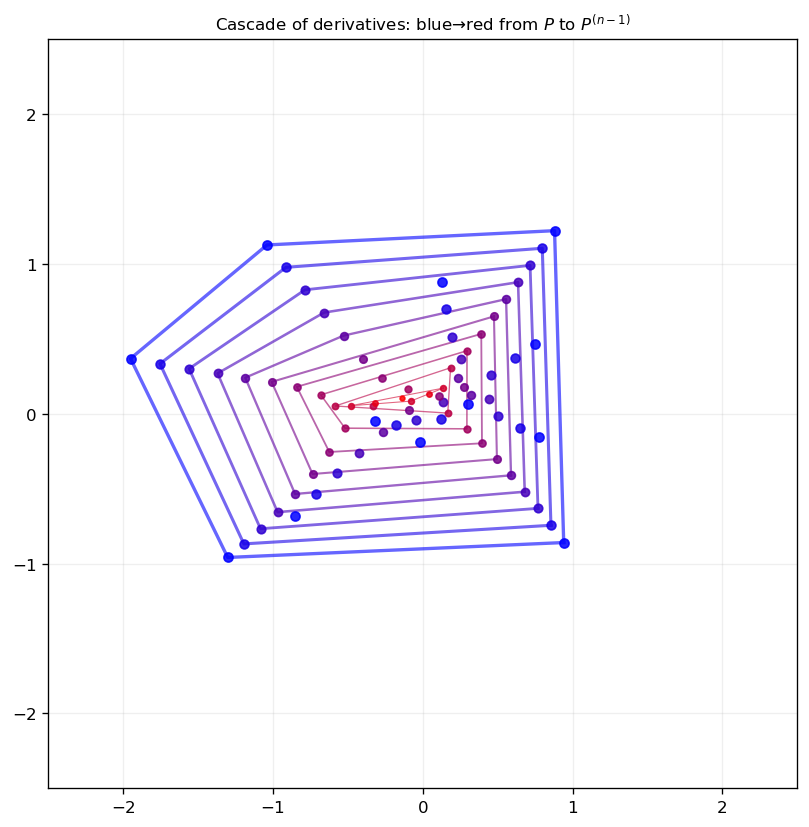

In [3]:
# Verify centroid preservation
print('Centroid of roots at each derivative level:')
for d, r in enumerate(all_roots):
    print(f'  d={d}: centroid = {r.mean():.4f}  (should all be ≈ {z0.mean():.4f})')
    if d >= 5: print('  ...'); break

# Multi-level plot
fig, ax = plt.subplots(figsize=(7, 7))
for d, r in enumerate(all_roots):
    t_norm = d / max(1, len(all_roots) - 1)
    col = (t_norm, 0, 1 - t_norm)
    size = max(4, 30 - 2*d)
    ax.scatter(r.real, r.imag, s=size, color=col, alpha=0.85, zorder=5+d)
    if len(r) >= 3:
        h = convex_hull_path(r)
        ax.plot(h[:, 0], h[:, 1], '-', lw=max(0.5, 2-0.15*d), color=col, alpha=0.6)

ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.set_title('Cascade of derivatives: blue→red from $P$ to $P^{(n-1)}$', fontsize=10)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

## Interactive: vary the root configuration

Change the seed to generate different polynomials and watch the root cascade. Increase the number of roots to see more dramatic hull shrinkage.

In [4]:
def show_gauss_lucas(n=10, seed=42):
    rng_i = np.random.default_rng(seed)
    z_i = rng_i.standard_normal(n) + 1j * rng_i.standard_normal(n)
    all_roots_i = poly_roots_derivatives(z_i, n)

    fig, ax = plt.subplots(figsize=(6, 6))
    for d, r in enumerate(all_roots_i):
        t_norm = d / max(1, len(all_roots_i) - 1)
        col = (t_norm, 0, 1 - t_norm)
        ax.scatter(r.real, r.imag, s=max(5, 40-3*d), color=col, alpha=0.9, zorder=5+d)
        if len(r) >= 3:
            h = convex_hull_path(r)
            ax.plot(h[:, 0], h[:, 1], '-', lw=max(0.5, 2-0.12*d), color=col, alpha=0.5)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    ax.set_title(f'$n={n}$ roots: Gauss–Lucas cascade')
    lim = max(2, np.abs(z_i).max() * 1.2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    plt.tight_layout(); plt.show()

interact(show_gauss_lucas,
         n=IntSlider(value=10, min=3, max=20, step=1, description='$n$ roots'),
         seed=IntSlider(value=42, min=0, max=100, step=1, description='seed'));

interactive(children=(IntSlider(value=10, description='$n$ roots', max=20, min=3), IntSlider(value=42, descrip…

## Bibliographical resources

- Lucas, F. (1879). Sur une application de la mécanique rationnelle à la théorie des équations. *Comptes Rendus de l'Académie des Sciences*, 89, 224–226.
- Marden, M. (1949). *The Geometry of the Zeros of a Polynomial in a Complex Variable*. AMS.
- Schur, I. (1921). Über Potenzreihen, die im Innern des Einheitskreises beschränkt sind. *Journal für die reine und angewandte Mathematik*, 148, 122–145.
- Rahman, Q. I. and Schmeisser, G. (2002). *Analytic Theory of Polynomials*. Oxford University Press.
- Fisk, S. (2006). Polynomials, roots, and interlacing. *ArXiv preprint* math/0612833.